# **COVID Analysis and Forecasting**

**Problem Statement: Given data about COVID 19 patients, write code to visualize the impact and analyze the trend of rate of infection and recovery as well as make predictions about the number of cases expected a week in future based on the current trends**

**Understand what is going inside the data and based on the same we will try to forecast the values for the upcoming**

# **Step 1 - Importing of Libraries**

#### **Configuration Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

#### **Classical Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
# plt.style.use("dark_background")

#### **Machine Learning Libraries**

<hr>

# **Step 2 - Data Loading**

### **Data Loading Phase**

In [ ]:
df = pd.read_csv("/content/covid19_dataset.csv")

###**Data Inspection**

In [ ]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


* **Province/State should be dropped**

In [ ]:
df = df.drop("Province/State", axis = 1)

### **Shape Inspection**

In [ ]:
print(f"Rows: {df.shape[0]} and Columns: {df.shape[1]}")

Rows: 49068 and Columns: 9


# **Find the insights within the data**

### **Finding the total number of Active Cases**

In [ ]:
# df["Active_Created"] = df["Confirmed"] - df["Deaths"] - df["Recovered"]

In [ ]:
# df["Active_Created"]

###**At the end of the dataset, when the last record was taken, so what was the current / latest values for the records**

**We are trying to find the last date, when the data was taken or collected. We are trying to compare the difference  or changes that we have seen as compared to initial data**

In [ ]:
top = df[df["Date"] == df["Date"].max()]

In [ ]:
top

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
48807,Afghanistan,33.939110,67.709953,2020-07-27,36263,1269,25198,9796,Eastern Mediterranean
48808,Albania,41.153300,20.168300,2020-07-27,4880,144,2745,1991,Europe
48809,Algeria,28.033900,1.659600,2020-07-27,27973,1163,18837,7973,Africa
48810,Andorra,42.506300,1.521800,2020-07-27,907,52,803,52,Europe
48811,Angola,-11.202700,17.873900,2020-07-27,950,41,242,667,Africa
...,...,...,...,...,...,...,...,...,...
49063,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


### **We should have the data based on country**

In [ ]:
w = df.groupby("Country/Region")[["Confirmed", "Active", "Deaths"]].sum().reset_index()

In [ ]:
w.head()

,Country/Region,Confirmed,Active,Deaths
0,Afghanistan,1936390,1089052,49098
1,Albania,196702,72117,5708
2,Algeria,1179755,345886,77972
3,Andorra,94404,19907,5423
4,Angola,22662,15011,1078


In [ ]:
w[w["Country/Region"] == "India"]

,Country/Region,Confirmed,Active,Deaths
79,India,40883464,15987913,1111831


**Visualizing the impact**

In [ ]:
fig = px.choropleth(
    w, # Data
    locations = "Country/Region", # Column from which the reference has been taken
    locationmode = "country names", # Show the country names
    color = "Confirmed", # Which column we consider while plotting
    hover_name = "Country/Region", #
    range_color = [1, 100000000],
    color_continuous_scale = "portland"
)

In [ ]:
fig.show()

### **Visualize all the confirmed cases**

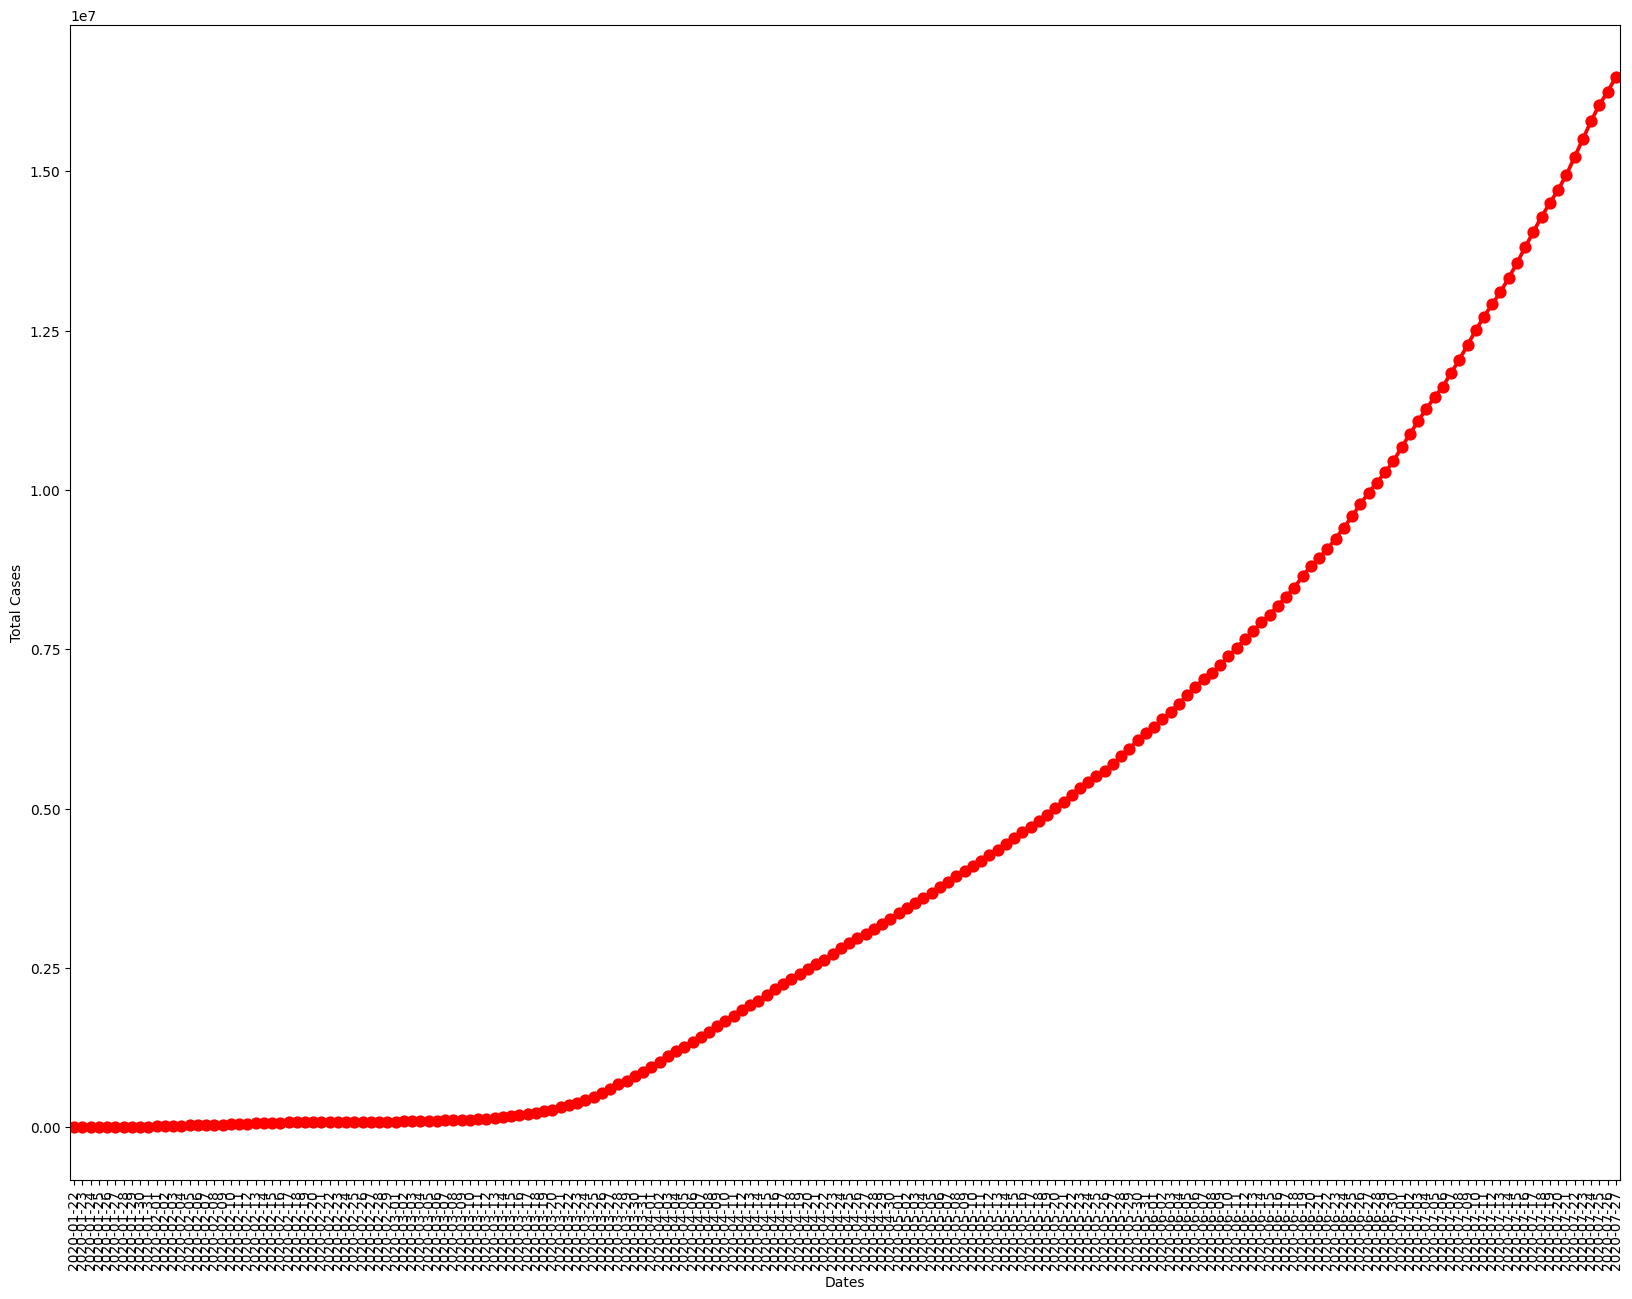

In [ ]:
plt.figure(figsize = (20, 15))

# Find the confirmed cases firtly
confirm_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

# We will convert this date column date-time
confirm_cases["Date"] = pd.to_datetime(confirm_cases["Date"])

# Create the plot here
a = sns.pointplot(
    x = confirm_cases.Date.dt.date,
    y = confirm_cases.Confirmed,
    color = "r"
)

a.set(xlabel = "Dates", ylabel = "Total Cases")

plt.xticks(rotation = 90)
plt.show()

<Figure size 2000x1500 with 0 Axes>

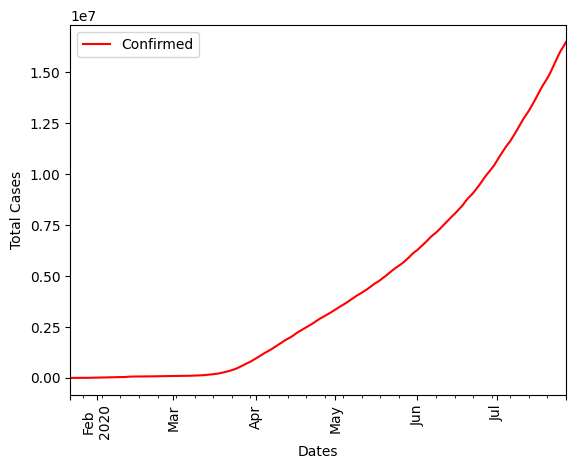

In [ ]:
plt.figure(figsize = (20, 15))

# Find the confirmed cases firtly
confirm_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

# We will convert this date column date-time
confirm_cases["Date"] = pd.to_datetime(confirm_cases["Date"])

# Create the plot here
confirm_cases = confirm_cases.set_index("Date")

a = confirm_cases.plot(kind = "line", color = "r")

a.set(xlabel = "Dates", ylabel = "Total Cases")

plt.xticks(rotation = 90)
plt.show()

In [ ]:
confirm_cases.head()

,Confirmed
Date,
2020-01-22,555
2020-01-23,654
2020-01-24,941
2020-01-25,1434
2020-01-26,2118


In [ ]:
# confirm_cases["Month"] = confirm_cases["Date"].dt.month

KeyError: 'Date'

In [ ]:
# confirm_cases["Date 1"] = confirm_cases["Date"].dt.date

In [ ]:
# confirm_cases.head()

# **Forecasting using Prophet**

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

In [ ]:
df.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


**Collected based on date**

In [ ]:
df.groupby("Date").sum().head()

,Country/Region,Lat,Long,Confirmed,Deaths,Recovered,Active,WHO Region
Date,,,,,,,,
2020-01-22,AfghanistanAlbaniaAlgeriaAndorraAngolaAntigua ...,5594.20365,6140.869714,555,17,28,510,Eastern MediterraneanEuropeAfricaEuropeAfricaA...
2020-01-23,AfghanistanAlbaniaAlgeriaAndorraAngolaAntigua ...,5594.20365,6140.869714,654,18,30,606,Eastern MediterraneanEuropeAfricaEuropeAfricaA...
2020-01-24,AfghanistanAlbaniaAlgeriaAndorraAngolaAntigua ...,5594.20365,6140.869714,941,26,36,879,Eastern MediterraneanEuropeAfricaEuropeAfricaA...
2020-01-25,AfghanistanAlbaniaAlgeriaAndorraAngolaAntigua ...,5594.20365,6140.869714,1434,42,39,1353,Eastern MediterraneanEuropeAfricaEuropeAfricaA...
2020-01-26,AfghanistanAlbaniaAlgeriaAndorraAngolaAntigua ...,5594.20365,6140.869714,2118,56,52,2010,Eastern MediterraneanEuropeAfricaEuropeAfricaA...


In [ ]:
total_active_cases = df["Active"].sum()

In [ ]:
print('Total number of active cases around the world: ', total_active_cases)

Total number of active cases around the world:  396715350


**Creating the data for confirmed, recoverd and deaths**

In [ ]:
confirmed = df.groupby("Date").sum()["Confirmed"].reset_index()
deaths = df.groupby("Date").sum()["Deaths"].reset_index()
recovered = df.groupby("Date").sum()["Recovered"].reset_index()

In [ ]:
confirmed.head()

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [ ]:
confirmed.to_csv("confirmed.csv")

**Forecast for confirmed cases using Prophet**

In [ ]:
confirmed.columns = ["ds", "y"] # making the date (ds) and target (y)

In [ ]:
confirmed["ds"] = pd.to_datetime(confirmed["ds"])

In [ ]:
confirmed.head()

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [ ]:
model = Prophet()

In [ ]:
model.fit(confirmed)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6xx66ypz/vfg25vxn.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6xx66ypz/jmpl1t4o.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=86458', 'data', 'file=/tmp/tmp6xx66ypz/vfg25vxn.json', 'init=/tmp/tmp6xx66ypz/jmpl1t4o.json', 'output', 'file=/tmp/tmp6xx66ypz/prophet_model8xfxow6e/prophet_model-20241002031305.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
03:13:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:13:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods = 30)

In [ ]:
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
213,2020-08-22
214,2020-08-23
215,2020-08-24
216,2020-08-25


In [ ]:
forecast = model.predict(future)

In [ ]:
forecast[["ds", "yhat"]]

,ds,yhat
0,2020-01-22,-2.067684e+04
1,2020-01-23,-8.050948e+03
2,2020-01-24,5.827455e+03
3,2020-01-25,1.217668e+04
4,2020-01-26,8.405020e+03
...,...,...
213,2020-08-22,2.145056e+07
214,2020-08-23,2.164810e+07
215,2020-08-24,2.184268e+07
216,2020-08-25,2.203193e+07


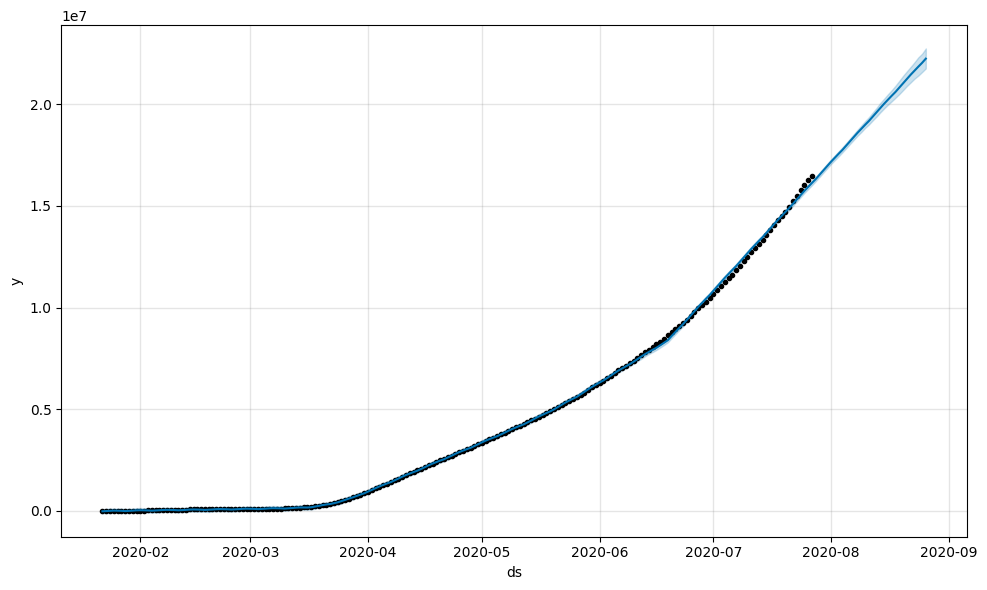

In [ ]:
confirmed_plot = model.plot(forecast)

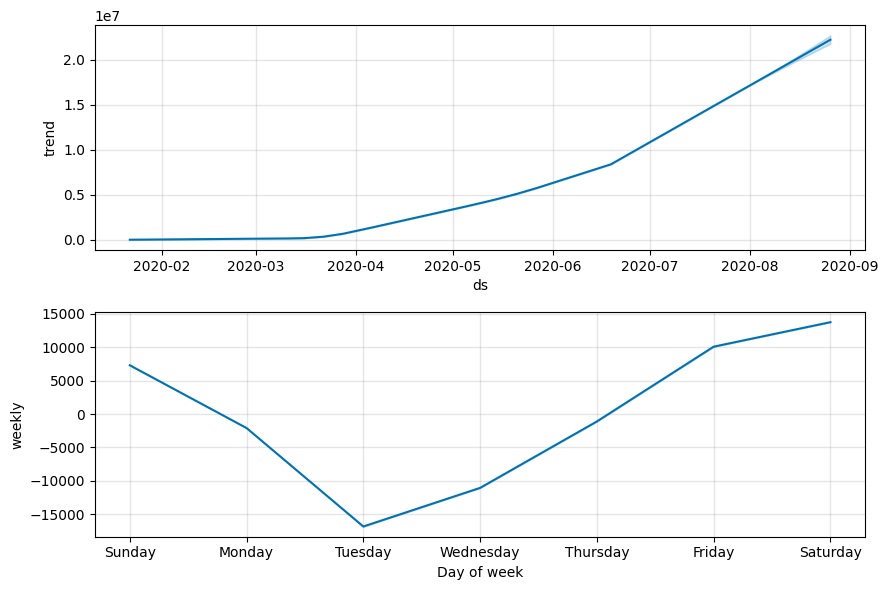

In [ ]:
confirm_plt_components = model.plot_components(forecast)

In [ ]:
air = pd.read_csv("/content/AirPassengers.csv")

**Step1 - To rename the date to ds, and target to y**

In [ ]:
air.columns = ["ds", "y"]

**Create your Model**

In [ ]:
m = Prophet()

**fit and make predict**

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6xx66ypz/kcrvy1v4.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6xx66ypz/wt5gq382.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=64556', 'data', 'file=/tmp/tmp6xx66ypz/kcrvy1v4.json', 'init=/tmp/tmp6xx66ypz/wt5gq382.json', 'output', 'file=/tmp/tmp6xx66ypz/prophet_modelmv3st05e/prophet_model-20241002031757.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
03:17:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
03:17:57 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


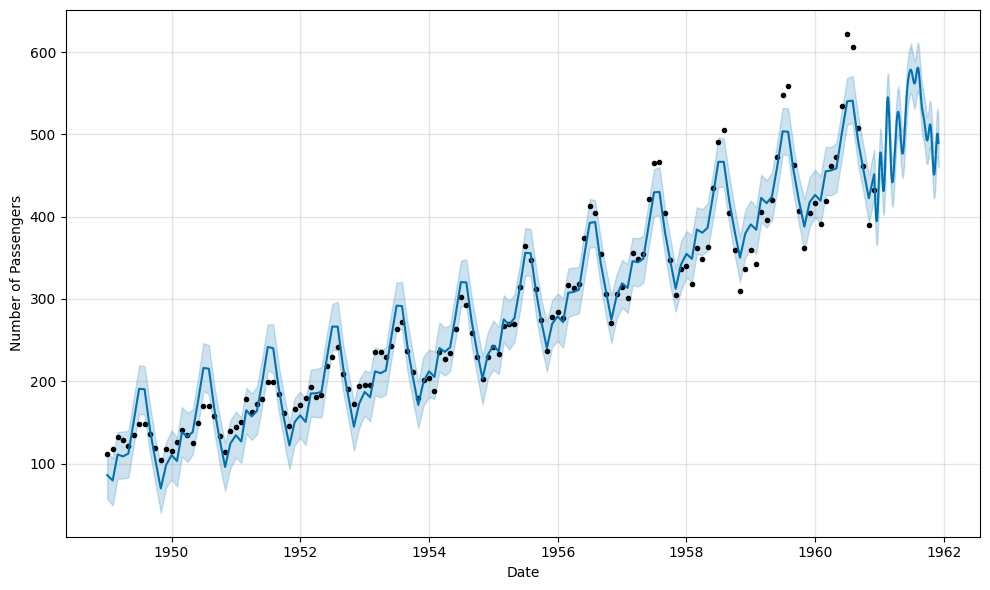

In [ ]:

m.fit(air)
future = m.make_future_dataframe(periods=365)
forecast = m.predict(future)
figure = m.plot(forecast, xlabel='Date', ylabel='Number of Passengers')



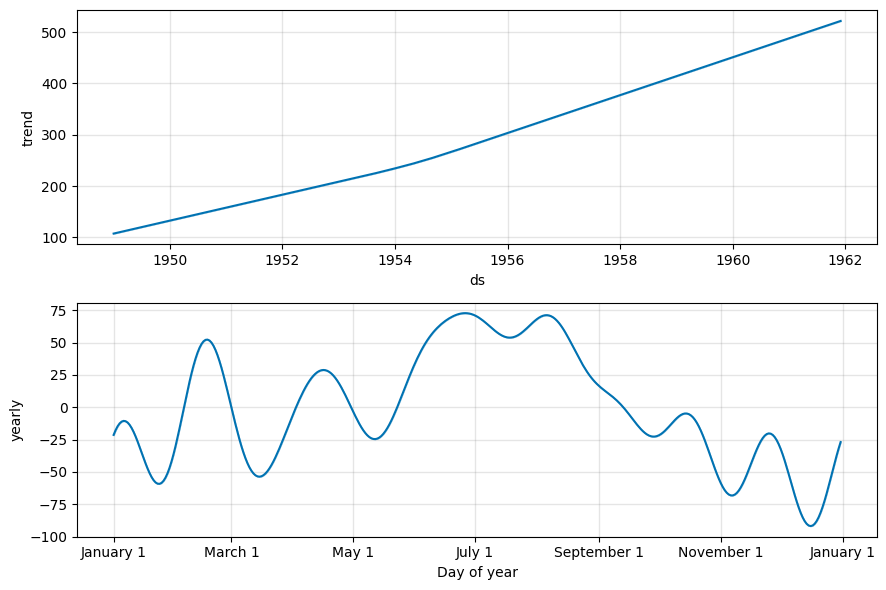

In [ ]:
confirm_plt_components = m.plot_components(forecast)